## Overview

This notebook is intended to:
* Quantify the number of EV chargers that could be installed/operated in a section of the grid (i.e. downstream from an HV/MV transformer) without overloading the transformer.

This use case is designed as follows:
  * Choose the grid of interest. 
  * Define the area of interest within the grid by choosing an HV/MV transformer.
  * Aggregate all loads downstream from the specific transformer.
  * Calculate the hourly available capacity in this grid section by subtracting the hourly aggregated load from the transformer's rating.
  * Quantify the additional EV chargers that could be installed/operated in this grid section based on the hourly available capacity.

Results of such analysis will provide valuable insights for decision-making on increasing capacity, managing transformer bottleneck, and permitting additional EV chargers. 

For more details about transformer capacity analysis for EV charging and how it can be analyzed using Awesense's platform, please refer to the [UC04-01 - Transformer Capacity Analysis for EV Charging](https://github.com/Awesense/edm-app-examples/blob/master/use_cases/usecase_descriptions/UC04-01%20-%20Transformer%20Capacity%20Analysis%20for%20EV%20Charging.pdf) document.

## Setup 

In [1]:
import getpass
import pandas as pd
import numpy as np
import urllib.parse
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Markdown as md

pd.set_option('display.max_columns', None)

**Connection**

Enter the EDM server address and the login credentials provided by Awesense. If you do not have the credentials, or have any trouble connecting, please contact api@awesense.com.
<span style='color:red'> **Please do NOT store the credentials in the notebook, nor share them with anyone.** </span>

In [2]:
edm_address = getpass.getpass(prompt='EDM server address: ')

print('\nEDM login information')
edm_name = getpass.getpass(prompt='Username: ')
edm_password = getpass.getpass(prompt='Password: ')
edm_password = urllib.parse.quote(edm_password)

%load_ext sql
%sql postgresql://$edm_name:$edm_password@$edm_address/edm
%config SqlMagic.displaycon = False
%config SqlMagic.feedback = False

# Delete the credential variables for security purposes.

del edm_name, edm_password

EDM server address:  ········



EDM login information


Username:  ········
Password:  ········


##### Custom Functions

In [3]:
def plot_available_capacity(df):
    """
    Plot a time series with hourly available capacity and box plots showing its distribution over the 
    months of the year and the hours of the day.  
    """
    
    # Create three subplots with titles. 
    fig = make_subplots(rows=3, cols=1, vertical_spacing=0.15,
                        subplot_titles = ('Hourly Available Capacity',
                                          'Hourly Available Capacity Distribution w.r.t Month of the Year',
                                          'Hourly Available Capacity Distribution w.r.t Hours of the Day'))
    
    # Plot hourly available capacity.
    fig.add_trace(go.Scatter(x = df['timestamp'], y = df['available_capacity'], 
                             showlegend = False), row=1, col=1)
    
    # Box plot of monthly distribution. 
    fig.add_trace(go.Box(x = df['timestamp'].dt.month, y = df['available_capacity'], 
                             showlegend=False), row=2, col=1)
    
    # Box plot of hourly distribution. 
    fig.add_trace(go.Box(x = df['timestamp'].dt.hour, y = df['available_capacity'],
                             showlegend=False), row=3, col=1)
    

    # Add a title, axis labels, axis ticks, and size the figure.
    fig.update_layout(title = 'Hourly Available Capacity Downstream of '+ grid_element_id)
    fig.update_xaxes(title_text = "Timestamp", row=1, col=1)
    fig.update_xaxes(title_text = "Months of the Year ", row=2, col=1)
    fig.update_xaxes(title_text = "Hours of the Day", row=3, col=1)
    fig.update_yaxes(title_text = "Hourly Available Capacity (kW)", row=1, col=1)
    fig.update_yaxes(title_text = 'Hourly Available Capacity (kW)', row=2, col=1)
    fig.update_yaxes(title_text = 'Hourly Available Capacity (kW)', row=3, col=1)
    fig.update_layout(xaxis2 = dict(tick0=1, dtick=1))
    fig.update_layout(xaxis3 = dict(tick0=1, dtick=1))
    fig.update_layout(height=1200, width=800)
    
    fig.show()
    

def calc_number_of_evs(df, ev_power):
    """
    Plot the number of EV chargers that could be installed per hourly available capacity.
    """
    
    # Calculate the number of EV chargers based on ev_power.
    df['EVs']=(df['available_capacity']/float(ev_power)).apply(np.floor)
    
    # Create the figure.
    fig = go.Figure()
                                         
    # Plot number of EV chargers.
    fig.add_trace(go.Scatter(x = df['timestamp'], y = df['EVs'],
                             showlegend = False))
    
    # Add a title, axis labels, axis ticks, and size the figure.
    fig.update_layout(title = 'Number of EV Chargers that Could Be Installed Downstream of  '+ grid_element_id)
    fig.update_yaxes(title_text = 'Number of EV Chargers')
    fig.update_xaxes(title_text = 'Timestamp')
    fig.update_layout(yaxis = dict(dtick=1))
    fig.update_layout(height = 400, width=800)
    
    fig.show()
    
    return df

---

## Use Case - Transformer Capacity Analysis for EV Chargers

#### Input Parameters
Input the grid name to find all the HV/MV transformers in this grid. 

In [4]:
# User input for the grid.
grid_id = input('Enter grid ID: ') # awefice

Enter grid ID:  awefice


### Data
#### Transformers Information
Fetch transformers and display the relevant information.

In [5]:
%%sql transformers <<

SELECT grid_element_id,
    meta ->> 'ownership' as ownership,
    meta ->> 'rating_kva' as rating_kva,
    meta ->> 'voltage_level' as voltage_level,
    meta ->> 'commission_date' as commission_date,
    meta ->> 'primary_voltage' as primary_voltage,
    meta ->> 'secondary_voltage' as secondary_voltage,
    phases
FROM grid_element
WHERE grid_id = '{grid_id}'
    AND type = 'Transformer'
    AND meta ->> 'voltage_level' = 'HV/MV';

Returning data to local variable transformers


In [6]:
# Convert the results to a data frame.
df_transformers = transformers.DataFrame()

if not df_transformers.empty:
    df_transformers['rating_kva'] = df_transformers['rating_kva'].astype(float)
    # Display the results.
    display(df_transformers)
else:
    raise ValueError(
    f" The grid_id '{grid_id}' does not have any transformers. Please enter a correct grid_id."
    )

,grid_element_id,ownership,rating_kva,voltage_level,commission_date,primary_voltage,secondary_voltage,phases
0,transformer_2,utility,20000.0,HV/MV,1989-01-01,200000,12500,ABC
1,transformer_6,utility,20000.0,HV/MV,1999-01-01,200000,12500,ABC


Choose a transformer from the above list.

In [7]:
# User input for the transformer.
grid_element_id = input('Enter transformer ID: ') # transformer_6

Enter transformer ID:  transformer_6


#### Meter Information
Fetch and display the meters downstream of the transformer.

In [8]:
%%sql meters <<

SELECT grid_element_id,
    type
FROM grid_get_downstream('{grid_id}', '{grid_element_id}', 'false')
WHERE type = 'Meter';

Returning data to local variable meters


In [9]:
# Convert the results to a data frame.
df_meters = meters.DataFrame()

if not df_meters.empty:
    # display the results.
    display(df_meters)
else:
    raise ValueError(
        f" The transformer_id '{grid_element_id}' does not have any meters downstream. Please choose a different transformer."
    )

,grid_element_id,type
0,m_16,Meter
1,m_17,Meter
2,m_18,Meter
3,m_19,Meter
4,m_20,Meter
5,m_21,Meter
6,m_22,Meter
7,m_23,Meter
8,m_24,Meter
9,m_25,Meter


#### Load
Fetch and display the hourly aggregate load downstream of the transformer. Hourly load is available from `2021-01-01 00:00:00 PST` until the present.

In [10]:
result = %sql WITH last_year AS ( \
                SELECT TSTZRANGE(NOW() - INTERVAL '1 year', NOW()) AS time_range \
              ), \
              transformers as ( \
                SELECT grid_id, grid_element_id AS transformer_id \
                  FROM grid_element \
                 WHERE type = 'Transformer' \
                  AND grid_id = '{grid_id}' \
                  AND meta->>'voltage_level' = 'HV/MV' \
                  AND grid_element_id = '{grid_element_id}' \
              ), \
              transformer_meter AS ( \
                SELECT t.grid_id, t.transformer_id, ggd.grid_element_id AS meter_id \
                  FROM transformers t \
                  JOIN grid_get_downstream(t.grid_id, t.transformer_id, false) ggd \
                    ON true \
                 WHERE ggd.type = 'Meter' \
              ), \
              meter_consumer_sources AS ( \
                SELECT geds_c.grid_element_data_source_id, tm.grid_id, tm.transformer_id, tm.meter_id \
                  FROM grid_element_data_source geds_c \
                  JOIN transformer_meter tm \
                    ON geds_c.grid_id = geds_c.grid_id \
                   AND geds_c.grid_element_id = tm.meter_id \
                 WHERE geds_c.type = 'CONSUMER' \
                   AND 'kWh' = ANY(metrics) \
              ), \
              meter_producer_sources AS ( \
                SELECT geds_p.grid_element_data_source_id, tm.grid_id, tm.transformer_id, tm.meter_id \
                  FROM grid_element_data_source geds_p \
                  JOIN transformer_meter tm \
                    ON geds_p.grid_id = geds_p.grid_id \
                   AND geds_p.grid_element_id = tm.meter_id \
                 WHERE geds_p.type = 'PRODUCER' \
                   AND 'kWh' = ANY(metrics) \
              ), \
              meter_consumption AS ( \
                SELECT mcs.transformer_id, mcs.meter_id, tdss_c.value, tdss_c.timestamp \
                  FROM meter_consumer_sources mcs \
                  JOIN last_year ly \
                    ON true \
                  JOIN ts_data_source_select(mcs.grid_element_data_source_id, 'kWh', ly.time_range) tdss_c \
                    ON true \
              ), \
              meter_production AS ( \
                SELECT mcp.transformer_id, mcp.meter_id, tdss_p.value, tdss_p.timestamp \
                  FROM meter_producer_sources mcp \
                  JOIN last_year ly \
                    ON true \
                  JOIN ts_data_source_select(mcp.grid_element_data_source_id, 'kWh', ly.time_range) tdss_p \
                    ON true \
              ) \
              SELECT mc.transformer_id, mc.timestamp at time zone 'America/Vancouver' as timestamp, \
                     SUM (mc.value - COALESCE(mp.value, 0)) as "total_kW" \
                FROM meter_consumption mc \
                LEFT JOIN meter_production mp \
                  ON mc.transformer_id = mp.transformer_id \
                 AND mc.meter_id = mp.meter_id \
                 AND mc.timestamp = mp.timestamp \
               GROUP BY mc.transformer_id, mc.timestamp \
              ;
              

# Convert the results to a data frame.
df_transformer_load = result.DataFrame()

# Merge the results with df_transformers to get `rating_kva`
df_transformer_load = pd.merge(df_transformer_load, df_transformers[['grid_element_id', 'rating_kva']], 
                               left_on='transformer_id', right_on='grid_element_id', how='left')


# Calculate the hourly available capacity. 
df_transformer_load['available_capacity'] = df_transformer_load['rating_kva']*0.98 - df_transformer_load['total_kW']

# Display the results.
df_transformer_load

,transformer_id,timestamp,total_kW,grid_element_id,rating_kva,available_capacity
0,transformer_6,2024-09-17 13:00:00,12.741074,transformer_6,20000.0,19587.258926
1,transformer_6,2024-09-17 14:00:00,11.446934,transformer_6,20000.0,19588.553066
2,transformer_6,2024-09-17 15:00:00,-7.563252,transformer_6,20000.0,19607.563252
3,transformer_6,2024-09-17 16:00:00,5.390816,transformer_6,20000.0,19594.609184
4,transformer_6,2024-09-17 17:00:00,4.448514,transformer_6,20000.0,19595.551486
...,...,...,...,...,...,...
8756,transformer_6,2025-09-17 09:00:00,-6.084909,transformer_6,20000.0,19606.084909
8757,transformer_6,2025-09-17 10:00:00,-13.377189,transformer_6,20000.0,19613.377189
8758,transformer_6,2025-09-17 11:00:00,-18.487307,transformer_6,20000.0,19618.487307
8759,transformer_6,2025-09-17 12:00:00,-22.595015,transformer_6,20000.0,19622.595015


### Visualization
#### Available Hourly Capacity
Plot the available hourly capacity downstream from the transformer and its distribution with respect to months of the year and hours of the day. 

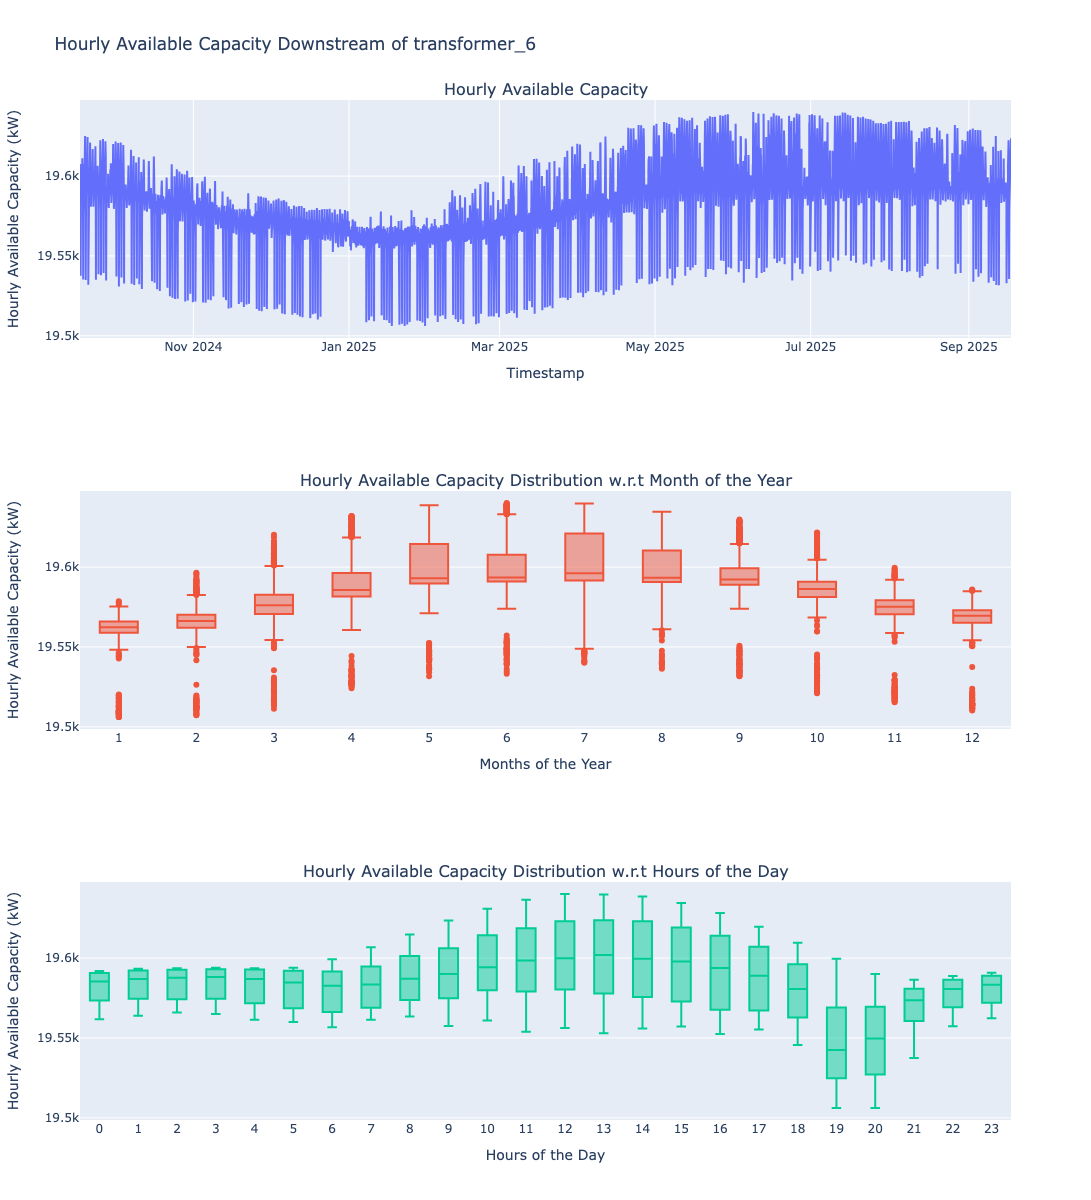

In [11]:
# Display the hourly available capacity and monthly variations. 
plot_available_capacity(df_transformer_load)

Hourly available capacity is higher during the summer and lower during the winter (winter peaking service area). The distribution of the hourly available capacity shows significant variability within the hours, while the median does not vary much across the hours. In contrast, the distribution of the hourly available capacity shows less variability each month but more visible median changes from month to month. Distribution plots can also be used to gain insight into Time of Use rates in selected grid sections.  

#### EV Chargers Analysis

The maximum number of EV chargers that could be installed without overloading the transformer is calculated by dividing the hourly available capacity by the maximum EV charging power. This calculation assumes the worst-case scenario where all the EV chargers run simultaneously at maximum load.

In [12]:
# User input for EV Power. 
ev_max_power = input('Enter EV Charger Maximum Power (kW): ') # 15

Enter EV Charger Maximum Power (kW):  15


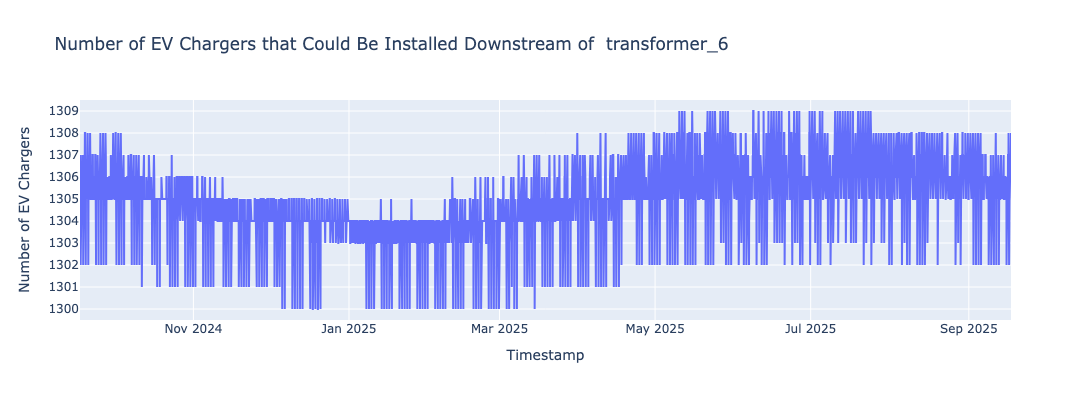

In [13]:
df_transformer_load = calc_number_of_evs(df_transformer_load, ev_max_power)

In [14]:
# Description of the plots above. 
md("The plot shows the number of EV chargers that could be installed and operated in this section of the grid.\
For the example with `transformer_6`, this number tends to be higher during the summer when the load is \
reduced and the hourly available capacity increases; and the reverse pattern holds for winter. However, \
if there are PV installations present in this section of the grid, the fluctuation in the number of \
EV chargers that could be installed and operated without overloading the transformers becomes more \
pronounced for each day.<br><br>\
Based on this analysis, the number of EV chargers that can be installed and operated year round \
(in the case of `{}` and EV charger with a maximum power of {} kW) is {}.".format(grid_element_id, ev_max_power, 
                                                                                              '%.0f' % df_transformer_load['EVs'].min() ))

The plot shows the number of EV chargers that could be installed and operated in this section of the grid.For the example with `transformer_6`, this number tends to be higher during the summer when the load is reduced and the hourly available capacity increases; and the reverse pattern holds for winter. However, if there are PV installations present in this section of the grid, the fluctuation in the number of EV chargers that could be installed and operated without overloading the transformers becomes more pronounced for each day.<br><br>Based on this analysis, the number of EV chargers that can be installed and operated year round (in the case of `transformer_6` and EV charger with a maximum power of 15 kW) is 1300.

---